In [2]:
pip install torch torchvision matplotlib

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(),lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(),lr=0.0002)

epochs = 20

for epoch in range(epochs):

    for imgs,_ in loader:

        real_imgs = imgs.view(-1,784).to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train D
        outputs = D(real_imgs)
        d_real_loss = criterion(outputs,real_labels)

        z = torch.randn(batch_size,100).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs.detach())
        d_fake_loss = criterion(outputs,fake_labels)

        d_loss = d_real_loss + d_fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train G
        outputs = D(fake_imgs)

        g_loss = criterion(outputs,real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] D:{d_loss.item():.4f} G:{g_loss.item():.4f}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 311kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.12MB/s]


Epoch [1/20] D:0.2222 G:4.2326
Epoch [2/20] D:0.0057 G:6.5665
Epoch [3/20] D:0.1296 G:5.9099
Epoch [4/20] D:0.2219 G:7.0086
Epoch [5/20] D:0.0587 G:6.0280
Epoch [6/20] D:0.2378 G:5.2177
Epoch [7/20] D:0.4525 G:5.4326
Epoch [8/20] D:0.2033 G:4.0914
Epoch [9/20] D:0.6399 G:2.6763
Epoch [10/20] D:0.4197 G:3.6812
Epoch [11/20] D:0.5170 G:4.9351
Epoch [12/20] D:0.1997 G:4.4699
Epoch [13/20] D:0.3318 G:3.5676
Epoch [14/20] D:0.4044 G:3.9213
Epoch [15/20] D:0.5094 G:3.4225
Epoch [16/20] D:0.5348 G:4.1435
Epoch [17/20] D:0.5508 G:2.8218
Epoch [18/20] D:0.4775 G:2.6021
Epoch [19/20] D:0.5914 G:2.8706
Epoch [20/20] D:0.4827 G:3.5380


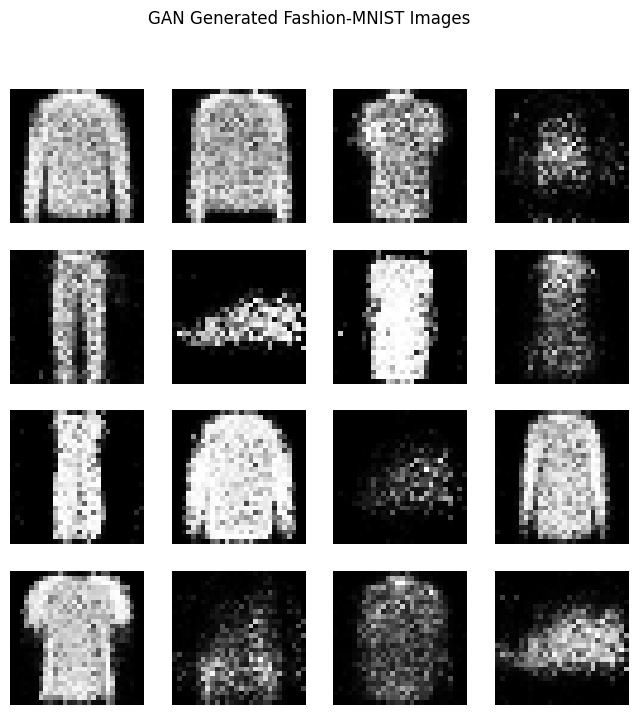

In [6]:
import matplotlib.pyplot as plt
import torch

G.eval()

with torch.no_grad():
    z = torch.randn(16,100).to(device) # Generate 16 images for the 4x4 grid
    generated_img = G(z)

generated_img = generated_img.cpu().view(-1,28,28)

fig,axes = plt.subplots(4,4,figsize=(8,8))

for i,ax in enumerate(axes.flat):
    ax.imshow(generated_img[i],cmap='gray')
    ax.axis('off')
plt.suptitle("GAN Generated Fashion-MNIST Images")
plt.show()

In [17]:
from torchvision.utils import save_image

# Ensure generated_img is in the correct shape (Batch, Channel, Height, Width)
# It was previously (Batch, Height, Width), so unsqueeze(1) adds the channel dimension.
generated_img = generated_img.unsqueeze(1)

# Normalize generated_img from [-1, 1] (from Tanh) to [0, 1]
# This is a robust way to normalize Tanh output for display.


save_image(
    generated_img,
    "gan_generated.png",
    nrow=4,
    normalize=True # Set to False as we've normalized manually
)

RuntimeError: output with shape [1, 1, 1] doesn't match the broadcast shape [1, 1, 1, 1, 1, 1, 1, 1, 28, 28]

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from diffusers import UNet2DModel
from diffusers import DDPMScheduler
from tqdm import tqdm

In [ ]:
device=torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Running on:",device)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset Loaded")

In [ ]:
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,

    layers_per_block=1,

    block_out_channels=(32, 64),

    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D"
    ),

    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D"
    )
).to(device)

print("Model Created")

In [ ]:
noise_scheduler=DDPMScheduler(
    num_train_timesteps=50
)

In [ ]:
optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=2e-4
)
